# 543. Diameter of Binary Tree
Given the root of a binary tree, return the length of the diameter of the tree.

The diameter of a binary tree is the length of the longest path between any two nodes in a tree. This path may or may not pass through the root.

The length of a path between two nodes is represented by the number of edges between them.

### Example 1

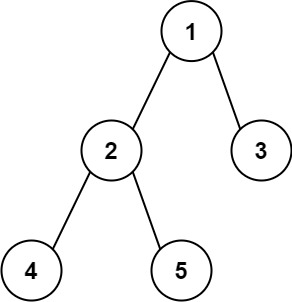

Input: root = [1,2,3,4,5]\
Output: 3\
Explanation: 3 is the length of the path [4,2,1,3] or [5,2,1,3].

### Example 2
Input: root = [1,2]\
Output: 1

### Constraints
* The number of nodes in the tree is in the range [1, 104].
* -100 <= Node.val <= 100


## Approach 1:
* Use recursive depth-first search in a separate or internal function `longestPath()` to find the longest path length from a node
* have an external or `nonlocal` variable `diameter = 0` to track the largest diameter seen thus far as we traverse the tree in `longestPath()`
* Use `longestPath()` to compare the paths of the left child vs right child at each node
* at each node, set `local_diameter` in `longestPath()` to equal the number of child nodes plus `longestPath(node.left)` plus `longestPath(node.right)`
* set `diameter = max(diameter, local_diameter)` at each node
* return `diameter` which should be the largest value for `local_diameter` we've seen so far

### Analysis
* Time Complexity: O(N)
    * we visit each node as we're doing the depth first search traversal
* Space Complexity: O(log(N))
    * space for the recursion stack when we're doing dfs, which will be equal to tree height
    * O(log(N)) is average case when tree is balanced
    * O(N) is worst case when tree is skewed

In [ ]:
from typing import Optional
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

def diameterOfBinaryTree(root: Optional[TreeNode]) -> int:
    diameter = 0
    def longestPath(root):
        nonlocal diameter
        if not root:
            return 0
        path = 0
        local_diameter= 0
        if root.left and root.right:
            local_diameter = 2
            path = 1
        elif root.left or root.right:
            local_diameter = 1
            path = 1

        left_path = longestPath(root.left)
        right_path = longestPath(root.right)
        path += max(left_path, right_path)
        local_diameter += left_path + right_path
        diameter = max(diameter,local_diameter)
        return path

    longestPath(root)
    return diameter